# Airline Customer Satisfaction Classification

## Problem Definition
Airline companies aim to improve customer satisfaction by understanding the factors that influence passengers’ experiences during flights. However, analyzing customer feedback manually is difficult due to the large volume of data and the variety of service-related attributes.

The objective of this project is to build a classification model that predicts whether an airline customer is satisfied or neutral/dissatisfied based on flight information, customer characteristics, and service quality ratings. The problem is formulated as a binary classification task, where the target variable represents customer satisfaction levels.


## Objective
The goal of this project is to build a classification model that predicts whether a customer is satisfied or neutral/dissatisfied based on their flight data and service ratings.


## Why it matters
Improving customer satisfaction leads to increased loyalty, fewer complaints, and higher profitability.

## How ML helps
By applying classical Machine Learning classification techniques, the model can automatically learn patterns from historical data and help airlines identify the most important factors affecting customer satisfaction. This can support data-driven decision-making to improve service quality and overall customer experience.


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Exploratory Data Analysis (EDA) & Feature Understanding

## Dataset Overview

The dataset provides insights into customer satisfaction levels within an undisclosed airline company. While the specific airline name is withheld, the dataset is rich in information, containing 22 columns and 129,880 rows. It aims to predict whether future customers will be satisfied based on various parameters included in the dataset.

The columns likely cover a range of factors that influence customer satisfaction, such as flight punctuality, service quality, and so. By analyzing this dataset, airlines can gain valuable insights into the factors that contribute to customer satisfaction and tailor their services accordingly to enhance the overall customer experience.

**Dataset link:** https://www.kaggle.com/datasets/raminhuseyn/airline-customer-satisfaction

## Dataset Features

- **Satisfaction:** Indicates the satisfaction level of the customer.
- **Customer Type:** Type of customer: 'Loyal Customer' or 'Disloyal Customer’.
- **Age:** Age of the customer.
- **Type of Travel:** Purpose of the travel: 'Business travel' or 'Personal Travel’.
- **Class:**	Class of travel: 'Business', 'Eco', or 'Eco Plus’.
- **Flight Distance:** The distance of the flight in kilometres
- **Seat comfort:** Rating of seat comfort provided during the flight (1 to 5).
- **Departure/Arrival time convenient** Rating of the convenience of departure/arrival time (1 to 5).
- **Food and drink:** Rating of food and drink quality provided during the flight (1 to 5).
- **Gate location:**	Rating of gate location convenience (1 to 5).
- **Inflight wifi service:**	Rating of inflight wifi service satisfaction (1 to 5).
- **Inflight entertainment:** Rating of inflight entertainment satisfaction (1 to 5).
- **Online support:** Rating of online customer support satisfaction (1 to 5).
- **Ease of Online booking:** Rating of ease of online booking satisfaction (1 to 5).
- **On-board service:** Rating of on-board service satisfaction (1 to 5).
- **Leg room service:** Rating of leg room service satisfaction (1 to 5).
- **Baggage handling:** Rating of baggage handling satisfaction (1 to 5).
- **Checkin service:** Rating of check-in service satisfaction (1 to 5).
- **Cleanliness:** Rating of cleanliness satisfaction (1 to 5).
- **Online boarding:** Rating of online boarding satisfaction (1 to 5).
- **Departure Delay in Minutes:** Total departure delay in minutes.
- **Arrival Delay in Minutes:** Total arrival delay in minutes.

In [ ]:
import kagglehub
raminhuseyn_airline_customer_satisfaction_path = kagglehub.dataset_download('raminhuseyn/airline-customer-satisfaction')

print('Data source import complete.')

100%|██████████| 1.59M/1.59M [00:00<00:00, 28.8MB/s]

Extracting files...


Data source import complete.


In [ ]:
# Reading the data

file_path = raminhuseyn_airline_customer_satisfaction_path + '/Airline_customer_satisfaction.csv'
data = pd.read_csv(file_path)
data.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [ ]:
data.shape

(129880, 22)

## Feature Type Identification

In [ ]:
data.dtypes

,0
satisfaction,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Seat comfort,int64
Departure/Arrival time convenient,int64
Food and drink,int64
Gate location,int64


In [ ]:
data.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [ ]:
data.describe(include = 'object')

,satisfaction,Customer Type,Type of Travel,Class
count,129880,129880,129880,129880
unique,2,2,2,3
top,satisfied,Loyal Customer,Business travel,Business
freq,71087,106100,89693,62160


In [ ]:
numeric = data.select_dtypes(include=['int64', 'float64']).columns
categorical = data.select_dtypes(include=['object']).columns
print('Numeric :', numeric)
print('Categorical :', categorical)

Numeric : Index(['Age', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')
Categorical : Index(['satisfaction', 'Customer Type', 'Type of Travel', 'Class'], dtype='object')


In [ ]:
for col in categorical:
  print(col, data[col].unique())

satisfaction ['satisfied' 'dissatisfied']
Customer Type ['Loyal Customer' 'disloyal Customer']
Type of Travel ['Personal Travel' 'Business travel']
Class ['Eco' 'Business' 'Eco Plus']



satisfaction => Binary

Customer Type => Binary

Type of Travel => Nominal

Class => Ordinal


## Missing values

In [ ]:
data.isna().sum()

,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


In [ ]:
data.isna().sum()/len(data)*100

,0
satisfaction,0.000000
Customer Type,0.000000
Age,0.000000
Type of Travel,0.000000
Class,0.000000
Flight Distance,0.000000
Seat comfort,0.000000
Departure/Arrival time convenient,0.000000
Food and drink,0.000000
Gate location,0.000000


## Feature Distribution

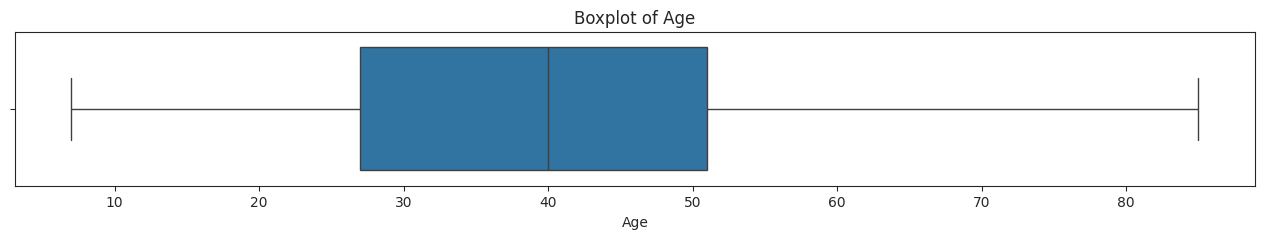

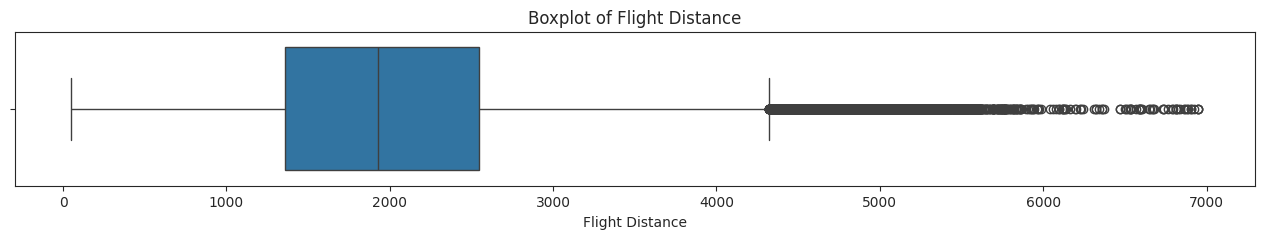

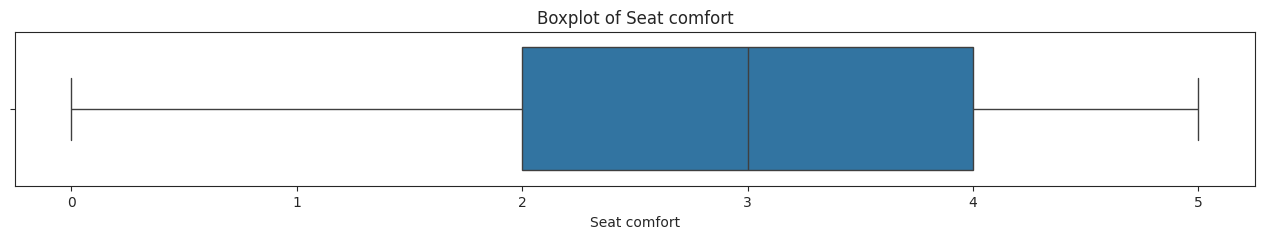

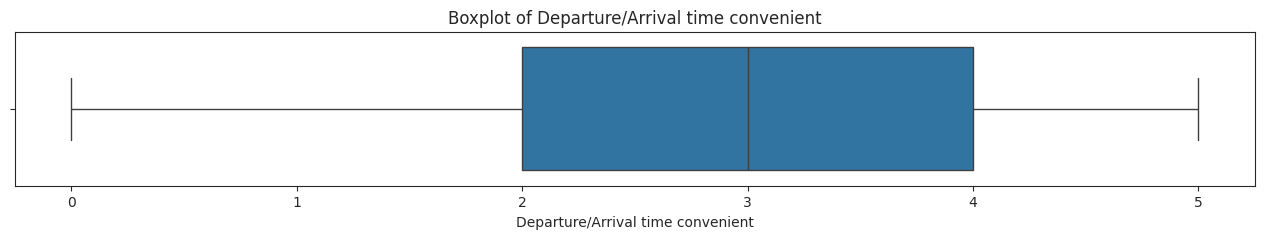

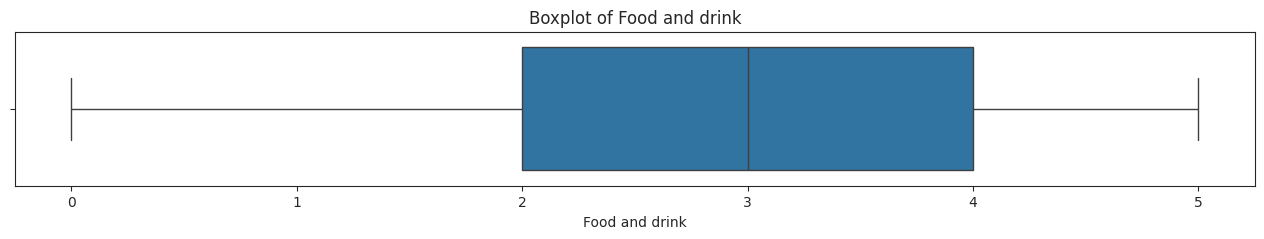

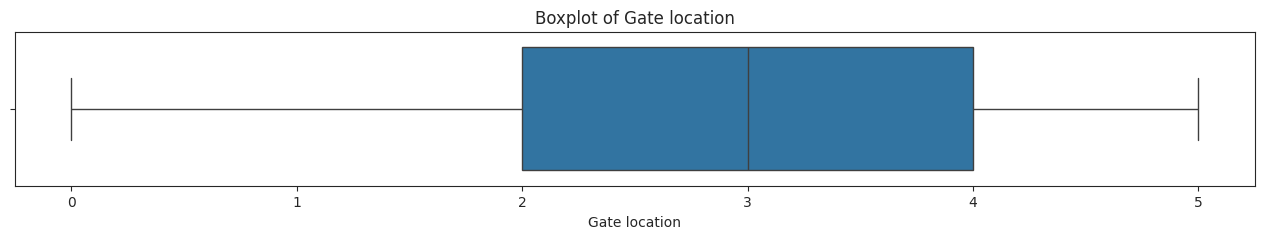

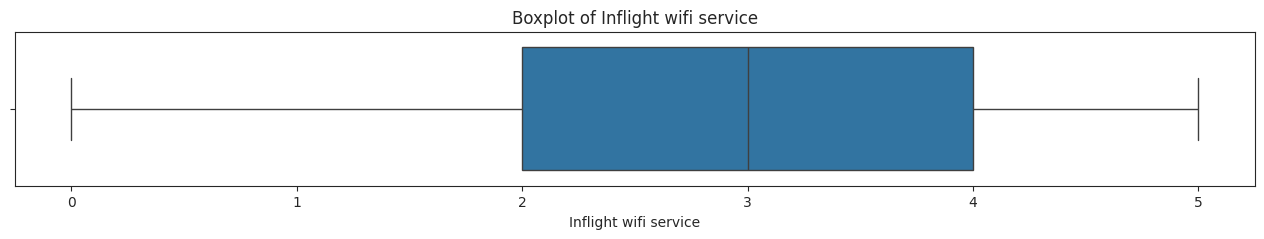

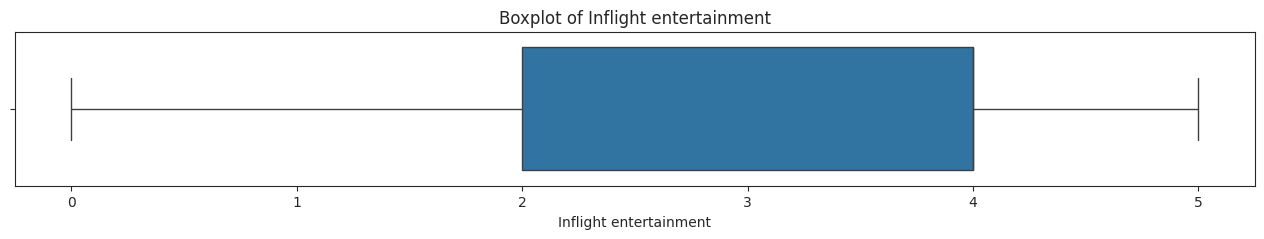

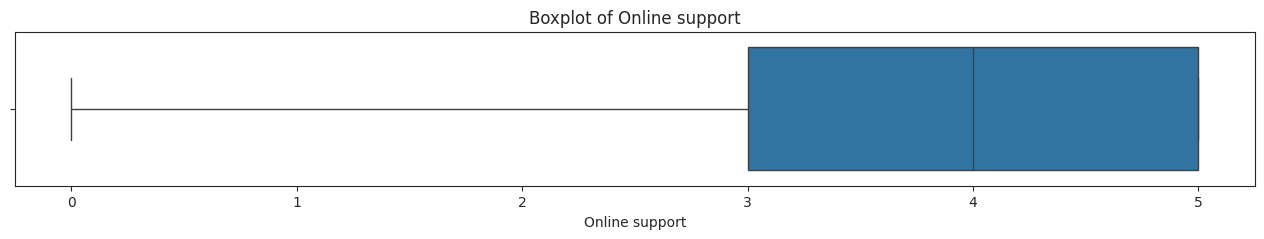

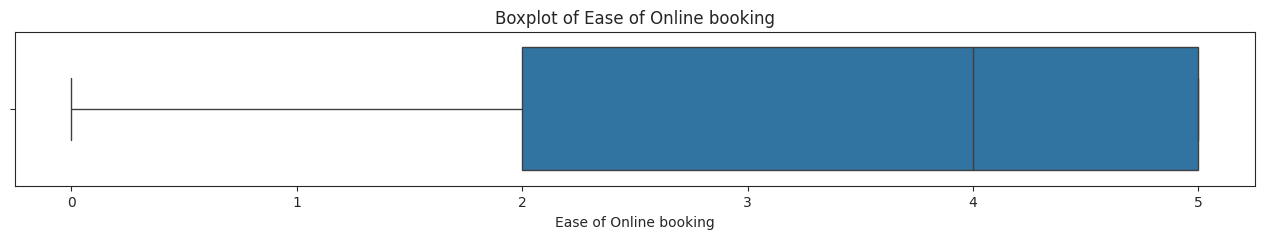

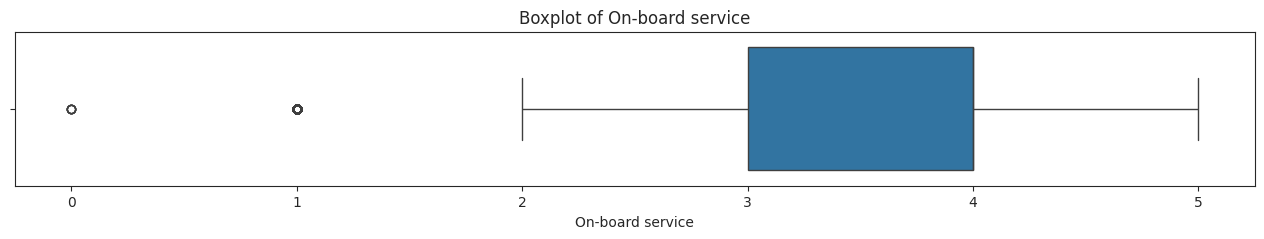

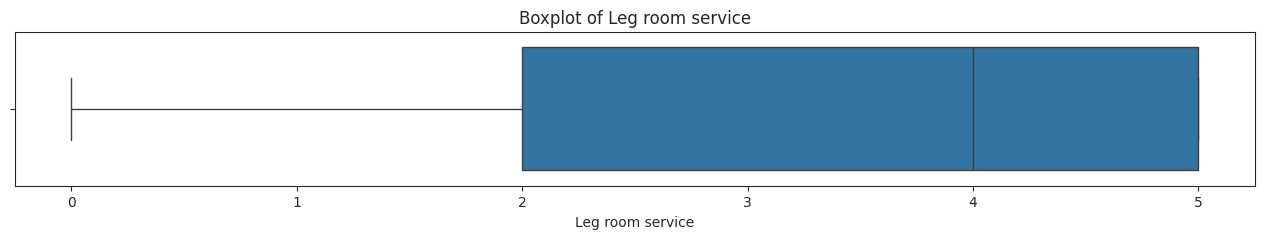

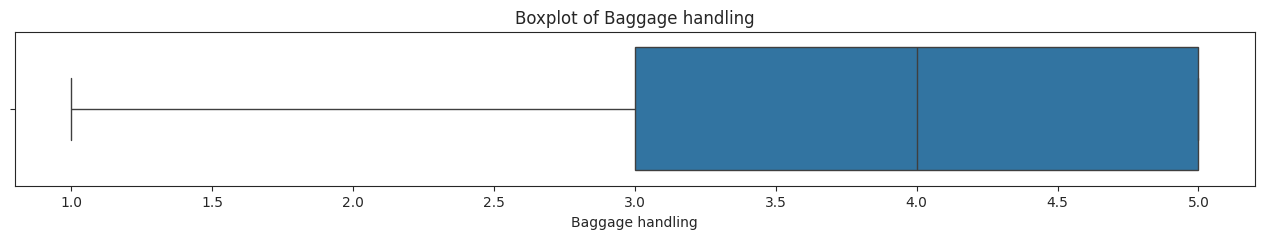

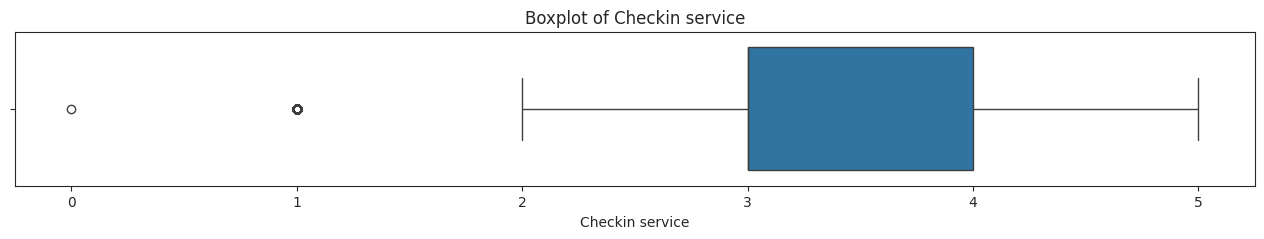

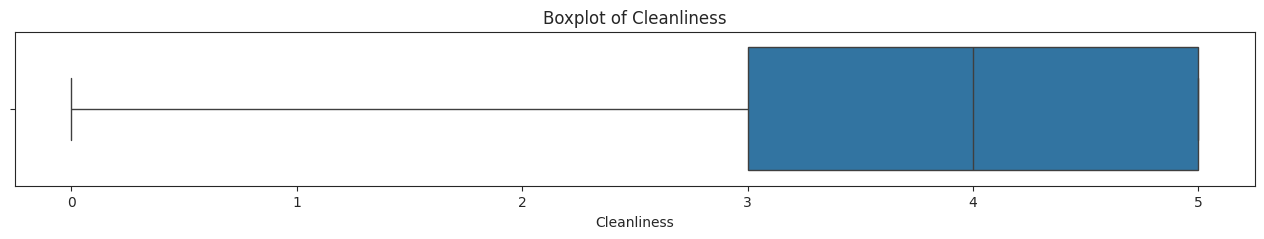

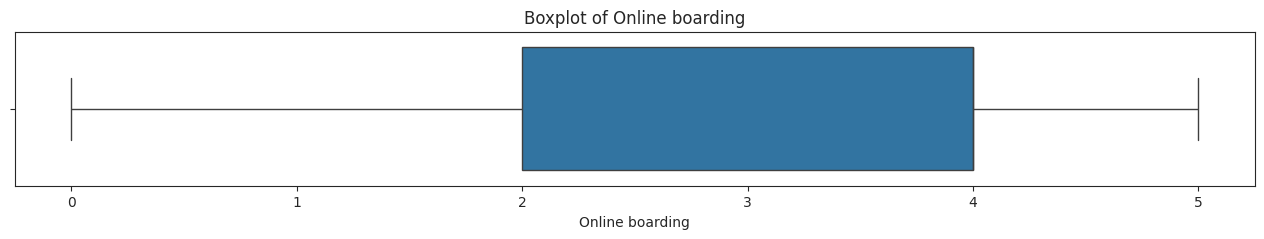

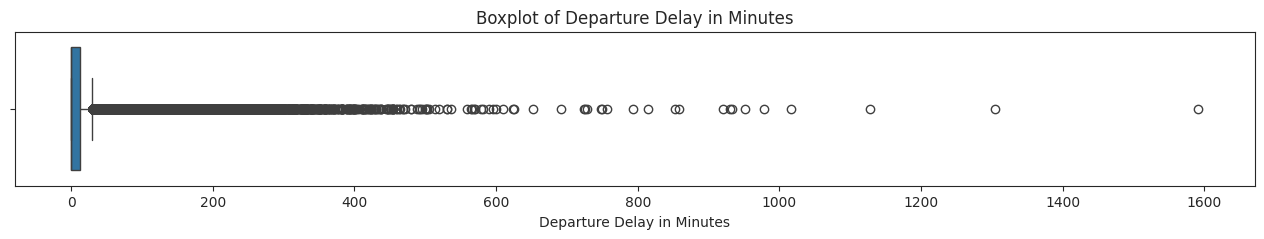

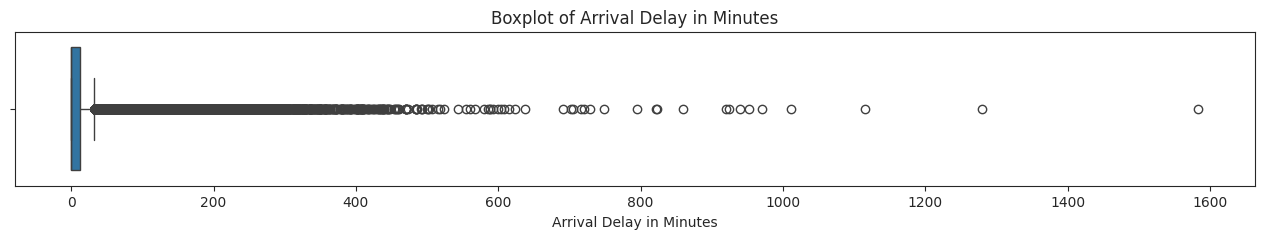

In [ ]:
for col in data.describe().columns:
    plt.figure(figsize=(16, 2))
    sns.set_style("ticks")
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

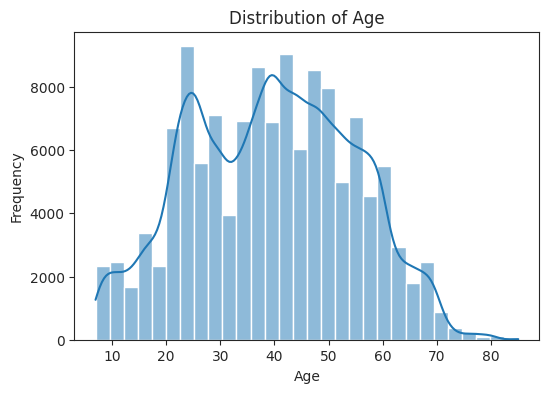

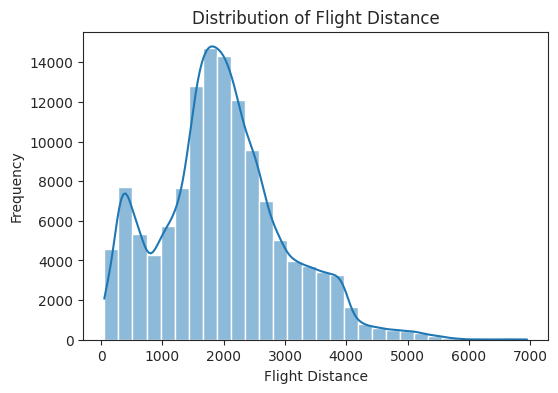

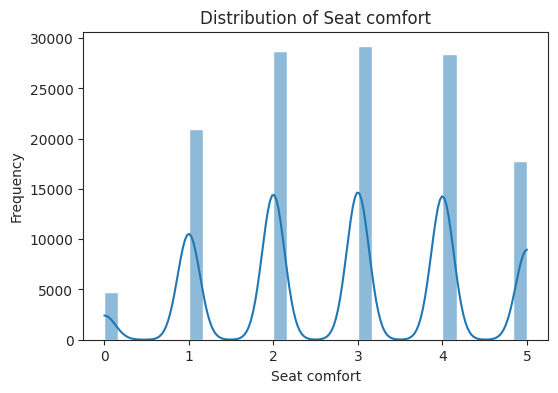

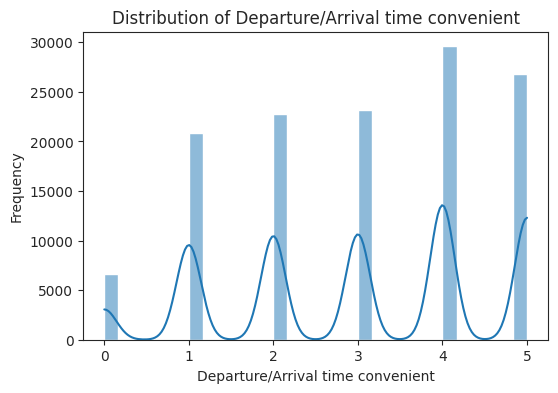

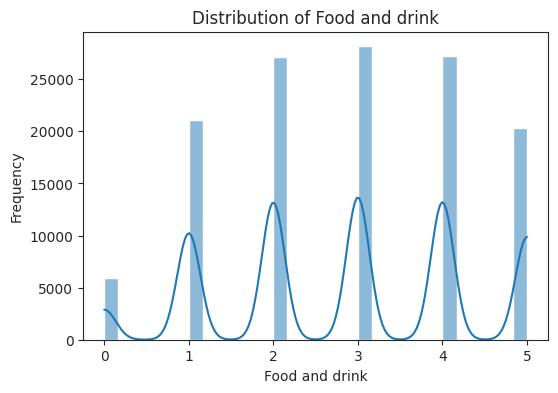

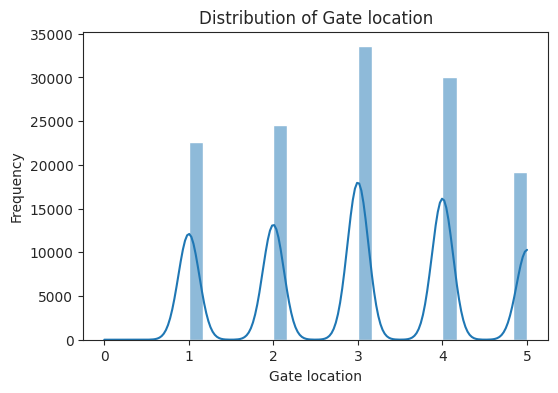

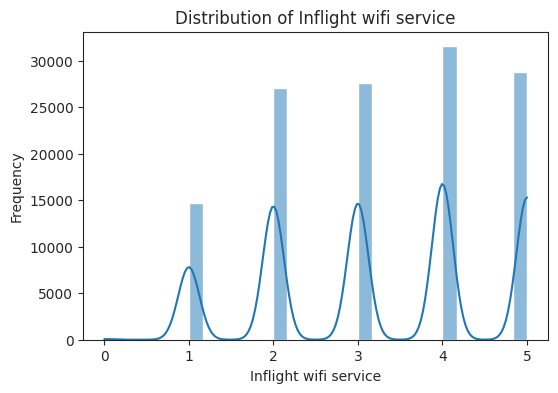

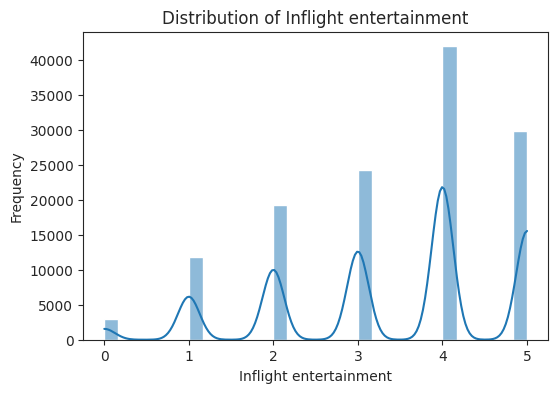

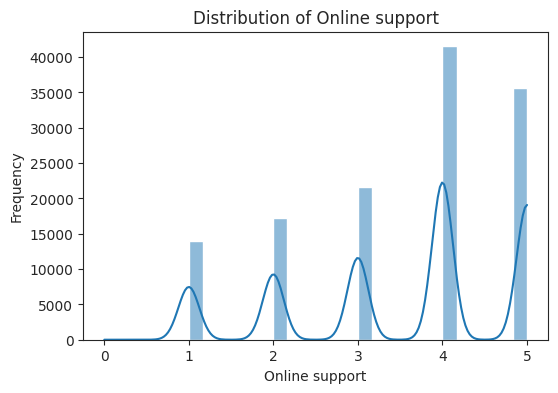

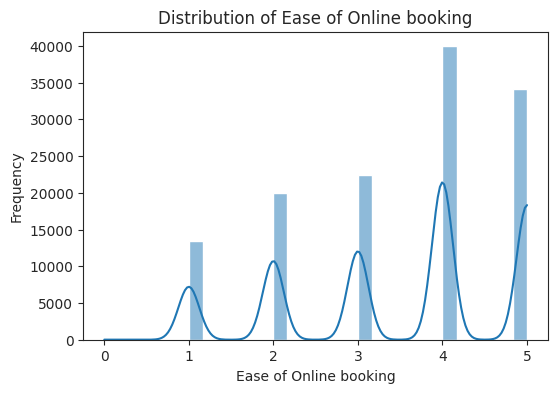

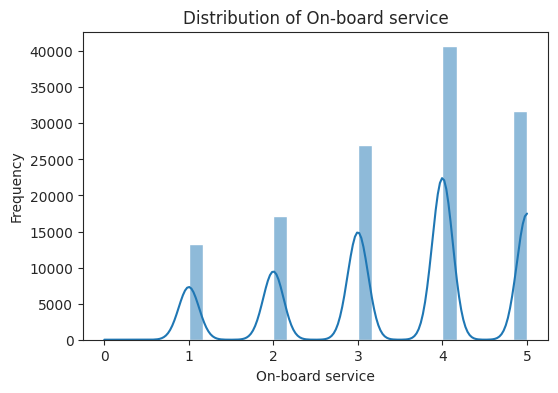

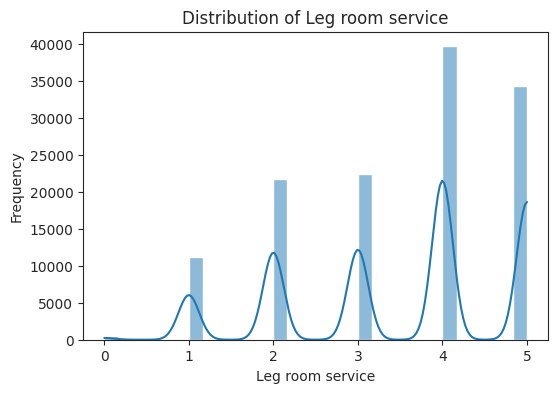

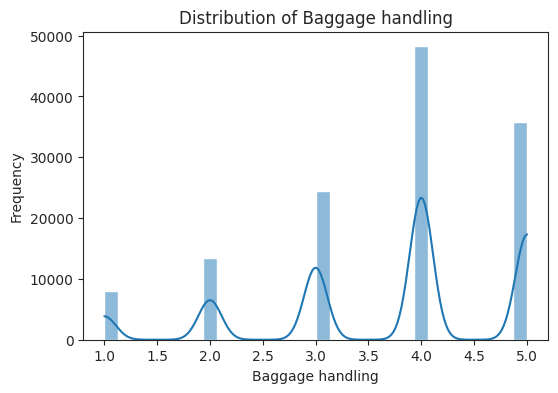

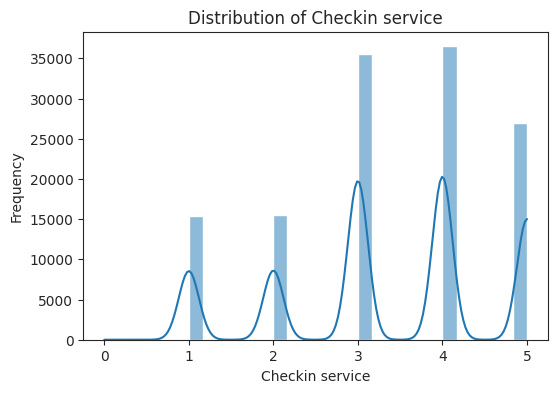

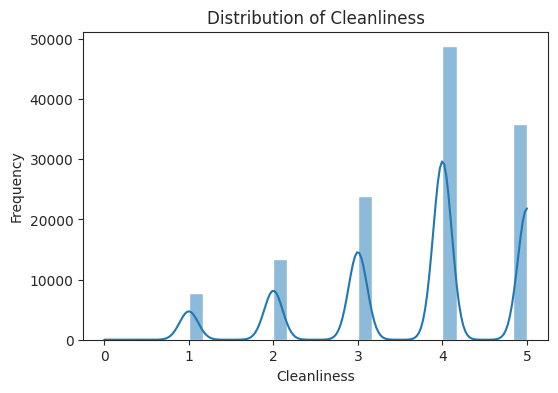

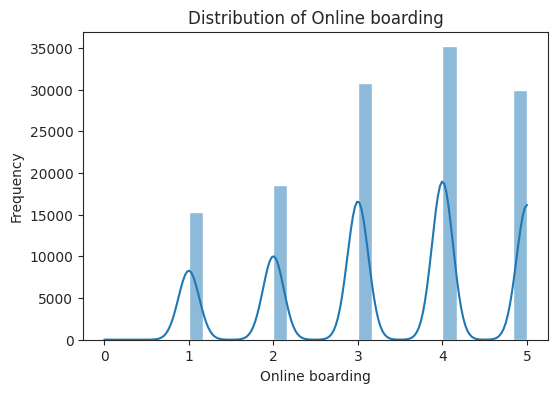

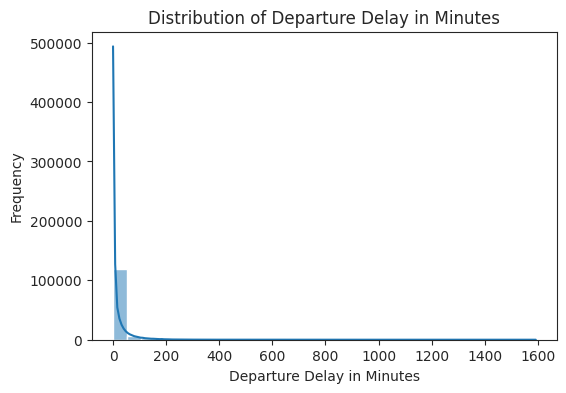

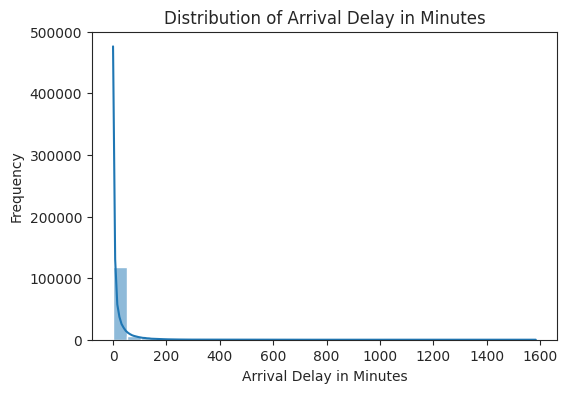

In [ ]:
for col in numeric:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')=
    plt.show()

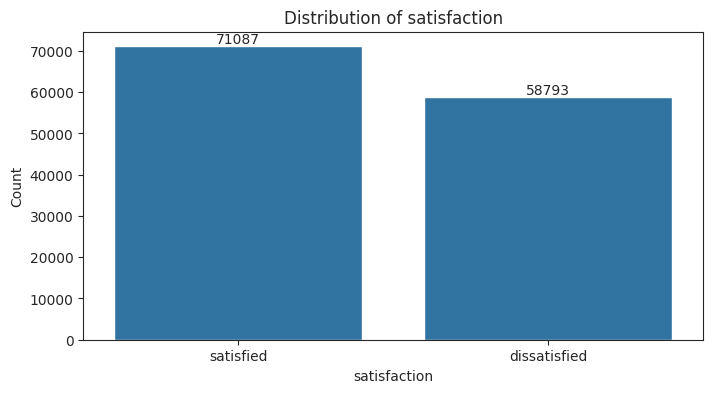

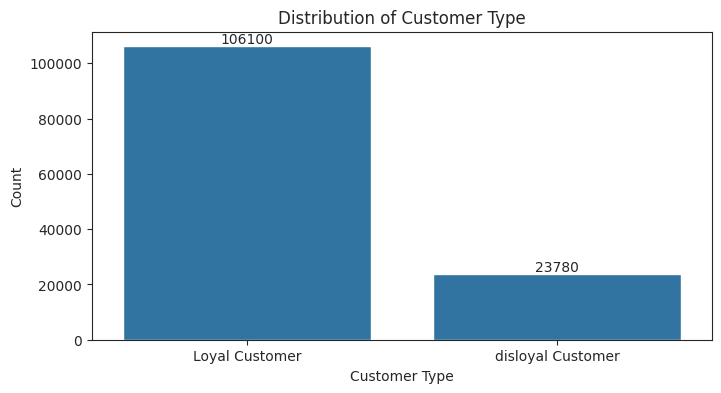

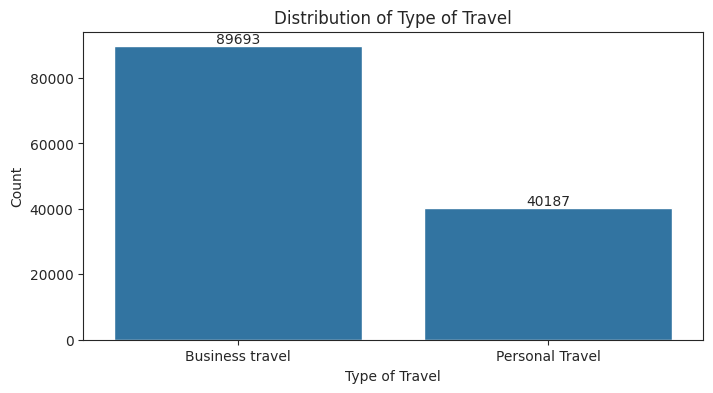

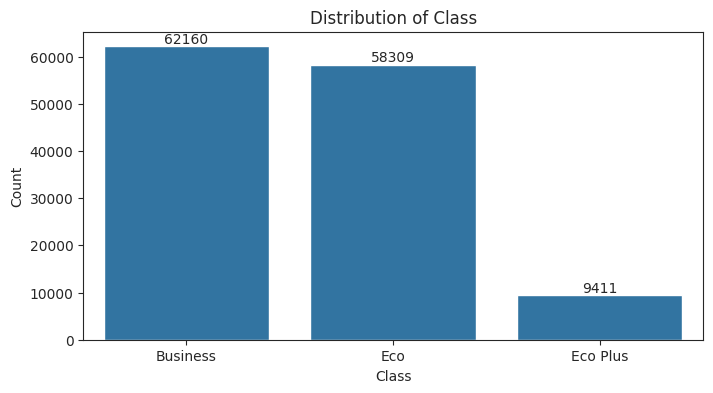

In [ ]:
for col in categorical:
    plt.figure(figsize=(8,4))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')


    for p in plt.gca().patches:
        plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=10)
    plt.show()

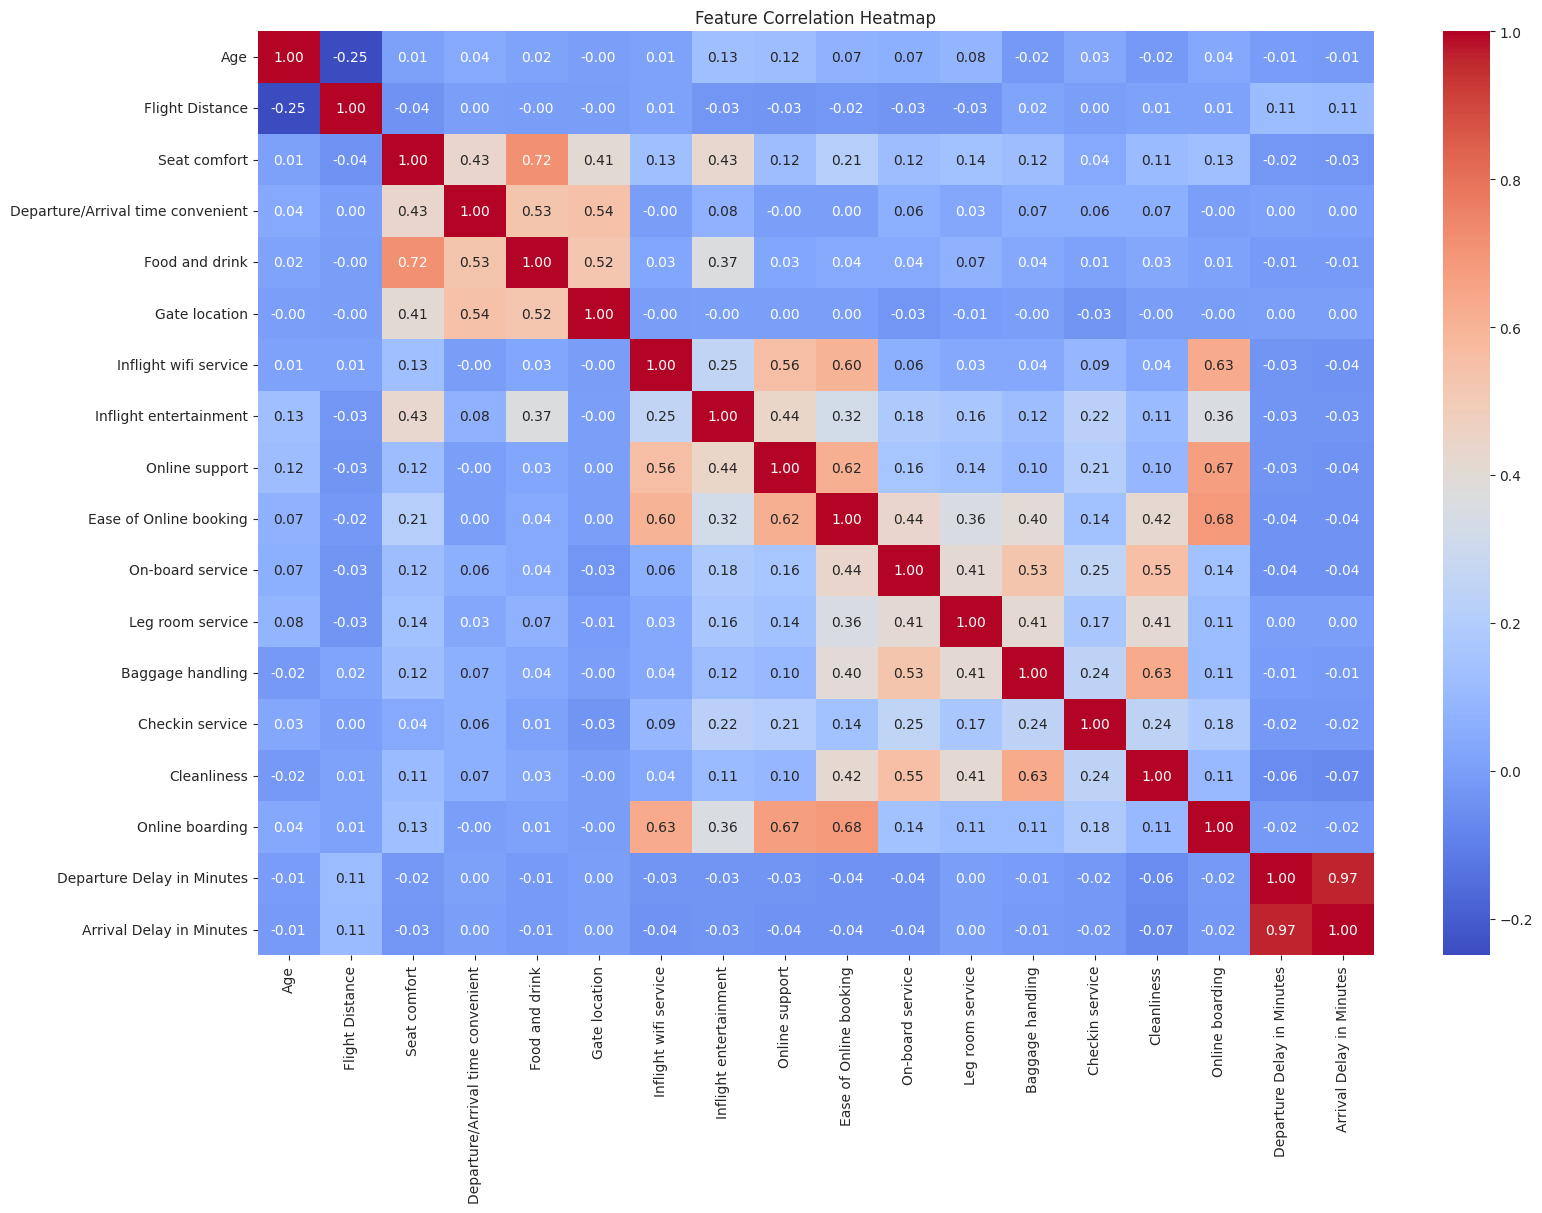

In [ ]:
plt.figure(figsize=(18, 12))
sns.heatmap(data[numeric].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

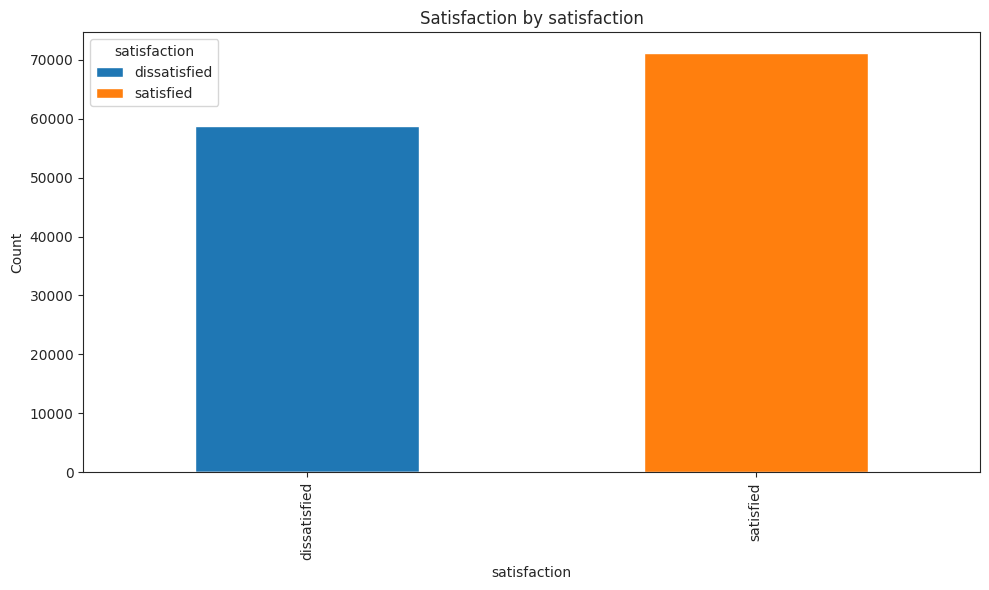

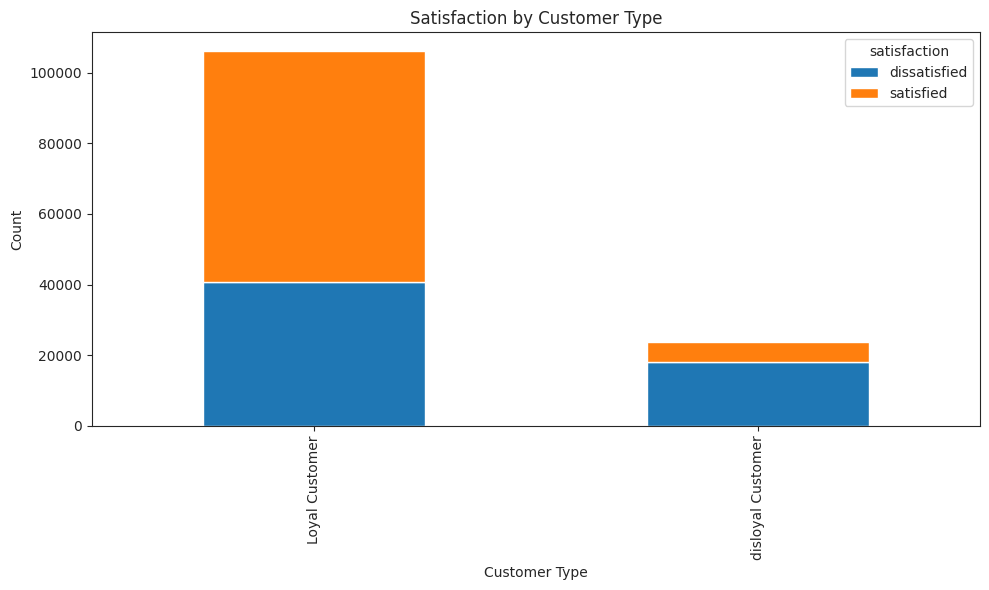

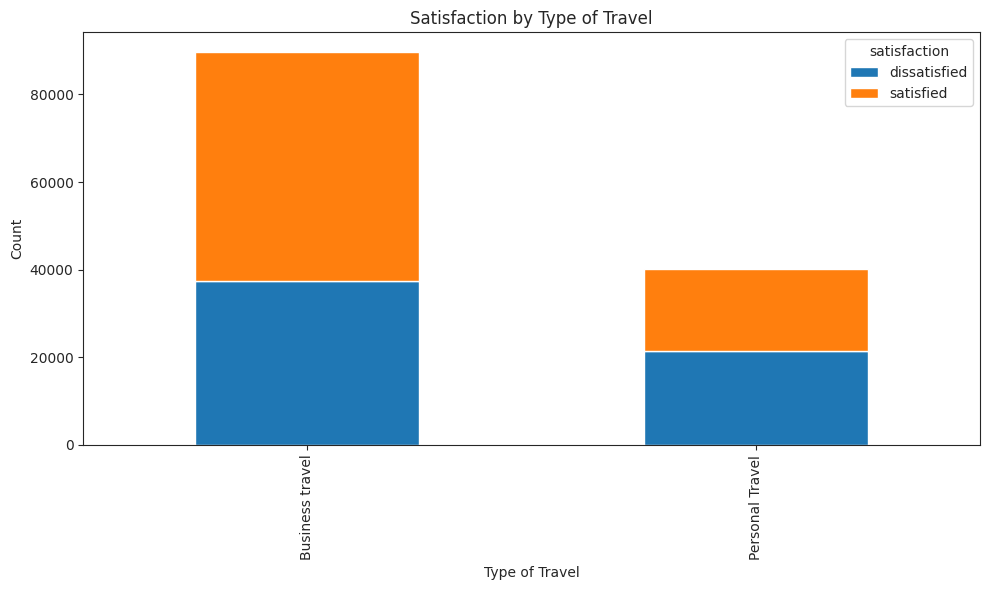

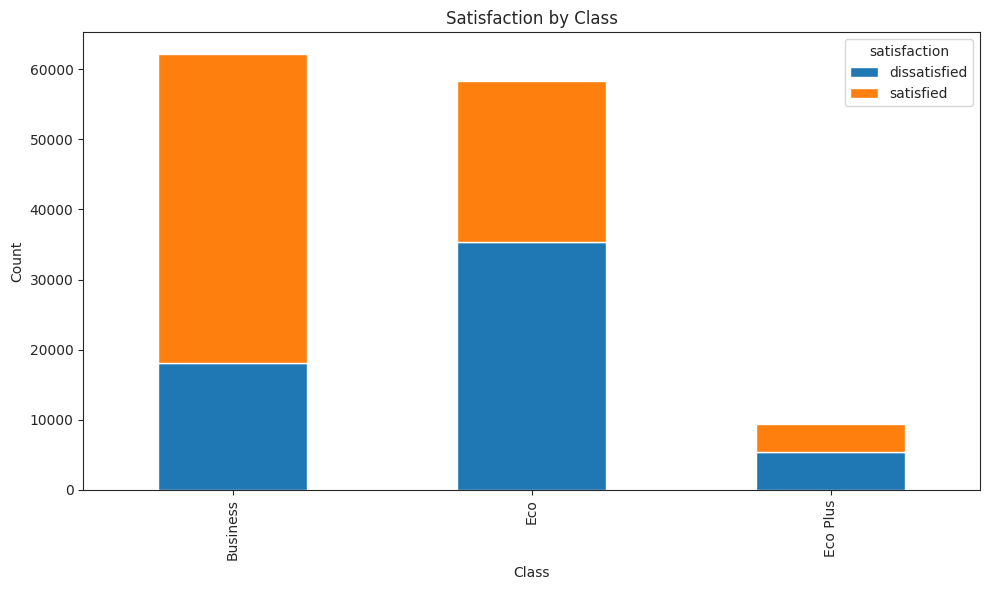

In [ ]:
for col in categorical:
    pivot = pd.crosstab(data[col], data['satisfaction'])
    pivot.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'Satisfaction by {col}')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## Class Distribution

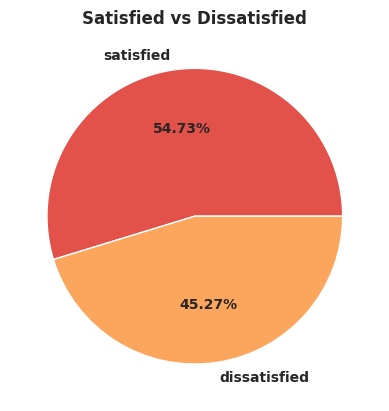

In [ ]:
plt.title("Satisfied vs Dissatisfied", fontsize = 12, weight='bold')
plt.pie(data['satisfaction'].value_counts(),labels=data['satisfaction'].value_counts().index,radius=1, autopct='%.2f%%',textprops={'fontsize': 10, 'fontweight': 'bold'}, colors = sns.color_palette('Spectral'))
plt.show()

# Summary of Insights

## 1. Feature Types and Preprocessing Needs

**A) Numerical Features**

Examples: Age, Flight Distance, Departure Delay in Minutes, Arrival Delay in Minutes

From the visualizations:

Histograms and boxplots show that:

Age has a near-normal distribution

Flight Distance is skewed

Departure and Arrival Delay contain large outliers

Recommended preprocessing:

Handle outliers


**B) Ordinal Categorical Features**

(Ratings from 0 to 5)

Examples: Seat comfort, Food and drink, Cleanliness, Online boarding, Inflight service, Baggage handling

From the visualizations:

Histograms show that:

Most ratings are between 3 and 5

The values are ordered and have numerical meaning

Recommended preprocessing:

Keep values as they are (0–5)

Do not apply one-hot encoding

Treat them as ordinal numerical features

**C) Nominal Categorical Features**

Examples: Customer Type (Loyal / Disloyal), Type of Travel (Business / Personal)

From the visualizations:

Bar charts show clear differences in satisfaction across categories

Recommended preprocessing:

Apply one-hot encoding Or binary encoding

**D) Target Variable**

Satisfaction (Satisfied / Dissatisfied)

This is a binary classification problem.

## 2. Is Scaling Needed?

From the visualizations:

Age ranges from 7 to 85

Flight Distance goes up to around 7000

Ratings range from 0 to 5

Delay values go up to around 1600

**Features are on very different scales.Yes, scaling is needed.**

Recommended methods:

StandardScaler

RobustScaler (preferred due to outliers)

## 3. Is Balancing Needed?

From the pie chart:

Satisfied ≈ 54.7%

Dissatisfied ≈ 45.3%

The difference is small.


**The data is balanced.**

No need for SMOTE, under-sampling, or over-sampling.

 # Data Preprocessing

 ## Handling Missing Values

In [ ]:
data.isna().sum()

,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


In [ ]:
# Filling by median is the best solution to overcome the outlier
data['Arrival Delay in Minutes'].fillna(data['Arrival Delay in Minutes'].median(),inplace=True)

In [ ]:
data.isna().sum()

,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


# Data Balancing

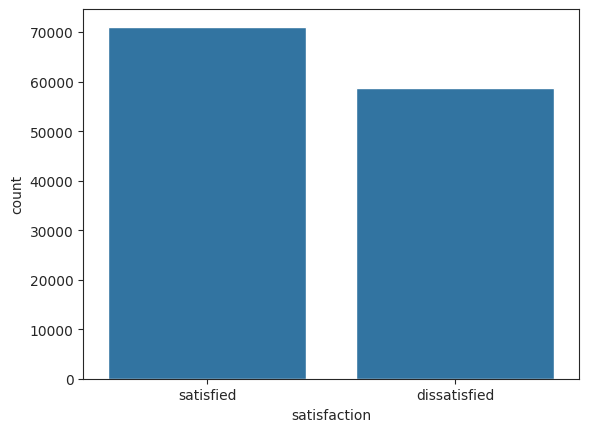

In [ ]:
sns.countplot(data=data, x='satisfaction')
plt.show()

## Encoding Categorical Features

In [ ]:
for col in categorical:
  print(col, data[col].unique())

satisfaction ['satisfied' 'dissatisfied']
Customer Type ['Loyal Customer' 'disloyal Customer']
Type of Travel ['Personal Travel' 'Business travel']
Class ['Eco' 'Business' 'Eco Plus']


In [ ]:
# Numeric encoding for Satisfaction (Target), Customer Type (Binary), Type of Travel (Nominal), and Class (Ordinal)
data_encoded = data.replace({
    'satisfaction': {'dissatisfied': 0, 'satisfied': 1},
    'Customer Type': {'disloyal Customer': 0, 'Loyal Customer': 1},
    'Type of Travel': {'Personal Travel': 0, 'Business travel': 1},
    'Class': {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
})

In [ ]:
print("Data Info after Encoding:")
data_encoded.info()

Data Info after Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  int64  
 1   Customer Type                      129880 non-null  int64  
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  int64  
 4   Class                              129880 non-null  int64  
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight ente

In [ ]:
data_encoded.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,1,65,0,0,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1,1,47,0,2,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1,1,15,0,0,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1,1,60,0,0,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1,1,70,0,0,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


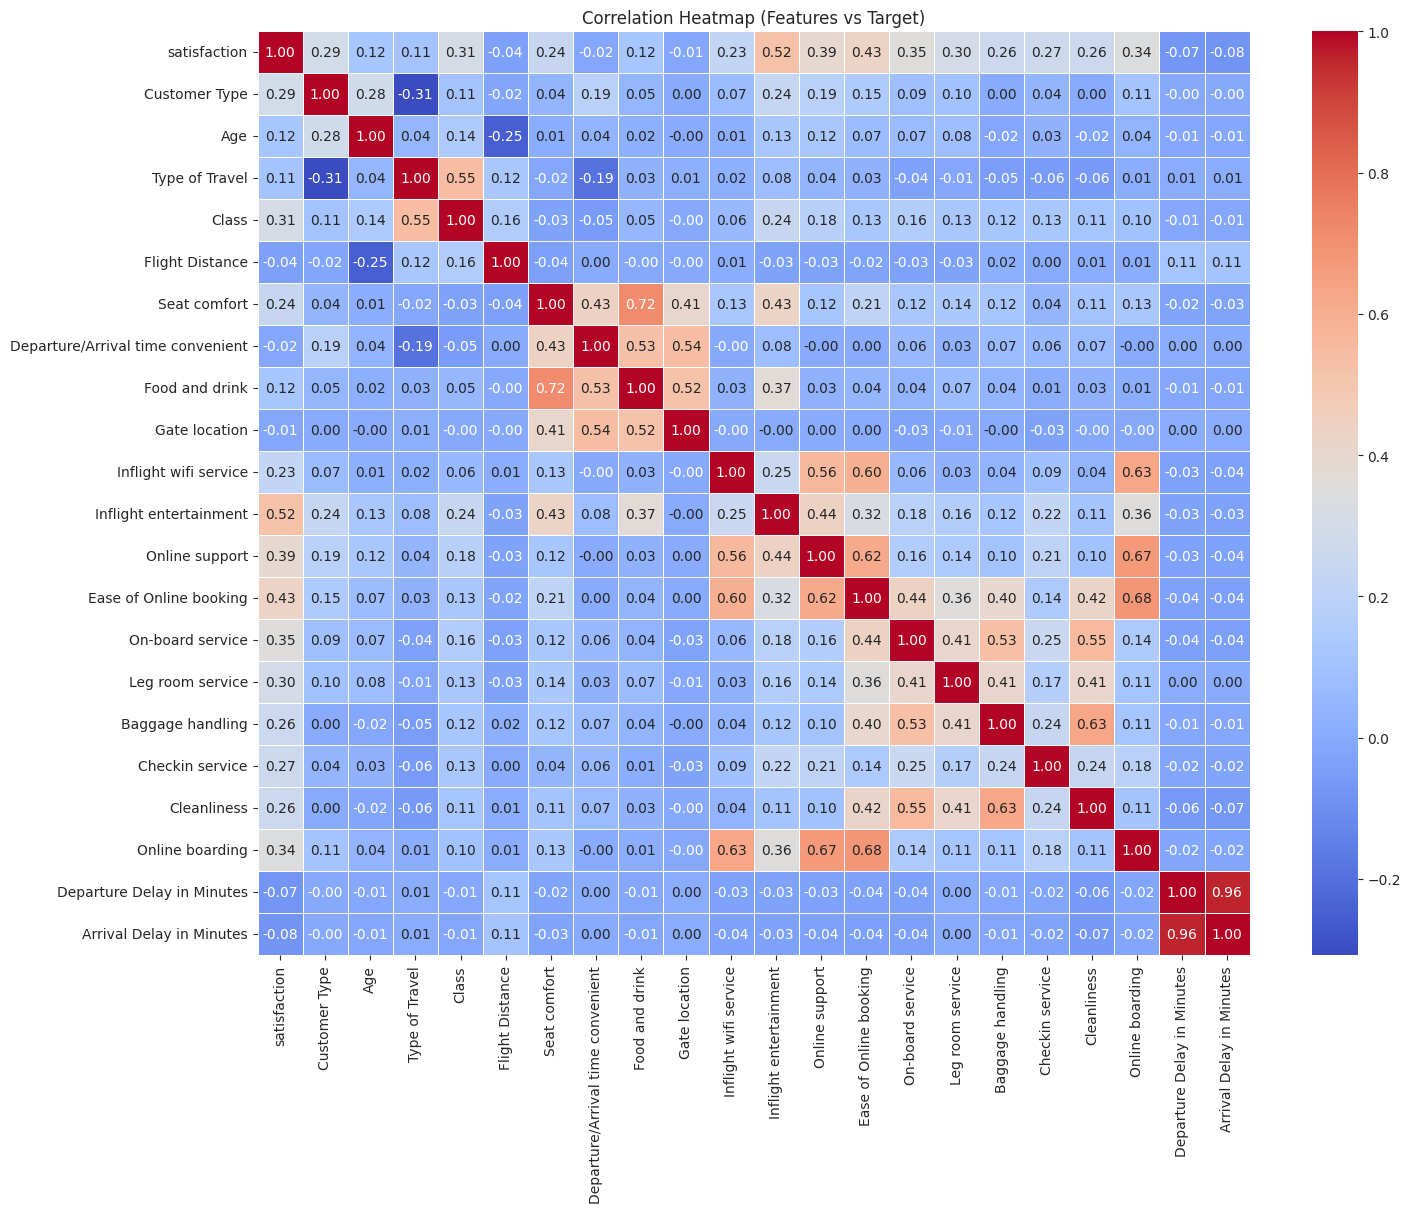

In [ ]:
corr_matrix = data_encoded.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Features vs Target)')
plt.show()

## Feature Scaling and Dataset Splitting

In [ ]:
data_input = data_encoded.drop(columns= 'satisfaction')
data_output = data_encoded['satisfaction']

In [ ]:
# Split the dataset to training and test sets
from sklearn.model_selection import train_test_split

# Test=30% & Train&Validation=70%
X, X_test, y, y_test = train_test_split(data_input, data_output, test_size=0.30, random_state=0)
#Validation=30% & Train=40%
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.30, random_state=0)

print('X_train: ', X_train.shape)
print('y_train: ', y_train.shape)
print('-'*50)
print('X_test', X_test.shape)
print('y_test', y_test.shape)
print('-'*50)
print('X_val', X_val.shape)
print('y_val', y_val.shape)

X_train:  (63641, 21)
y_train:  (63641,)
--------------------------------------------------
X_test (38964, 21)
y_test (38964,)
--------------------------------------------------
X_val (27275, 21)
y_val (27275,)


In [ ]:
# scaling features using RobustScaler to overcome outliers
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Model Building

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,ConfusionMatrixDisplay

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    print("-" * 30)
    print(f"Evaluation for: {model_name}")
    print("-" * 30)

    y_pred = model.predict(X_test)

    from sklearn.metrics import classification_report, confusion_matrix
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Dissatisfied', 'Satisfied'],
        yticklabels=['Dissatisfied', 'Satisfied']
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [ ]:
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(),
    'Random Forest Classifier': RandomForestClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
}

Training K-Nearest Neighbors...
------------------------------
Evaluation for: K-Nearest Neighbors
------------------------------
              precision    recall  f1-score   support

           0       0.87      0.91      0.89     12399
           1       0.93      0.89      0.91     14876

    accuracy                           0.90     27275
   macro avg       0.90      0.90      0.90     27275
weighted avg       0.90      0.90      0.90     27275



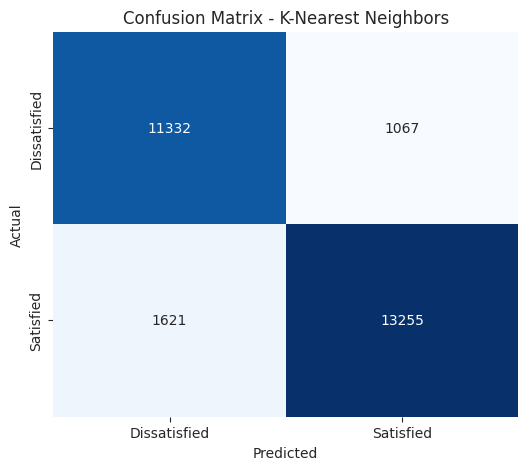

Training Logistic Regression...
------------------------------
Evaluation for: Logistic Regression
------------------------------
              precision    recall  f1-score   support

           0       0.82      0.81      0.81     12399
           1       0.84      0.85      0.84     14876

    accuracy                           0.83     27275
   macro avg       0.83      0.83      0.83     27275
weighted avg       0.83      0.83      0.83     27275



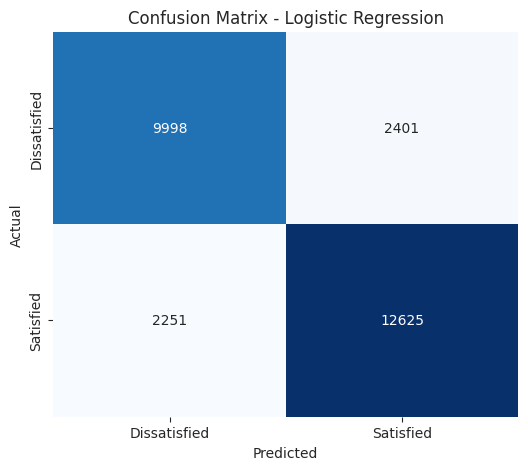

Training Random Forest Classifier...
------------------------------
Evaluation for: Random Forest Classifier
------------------------------
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     12399
           1       0.96      0.95      0.96     14876

    accuracy                           0.95     27275
   macro avg       0.95      0.95      0.95     27275
weighted avg       0.95      0.95      0.95     27275



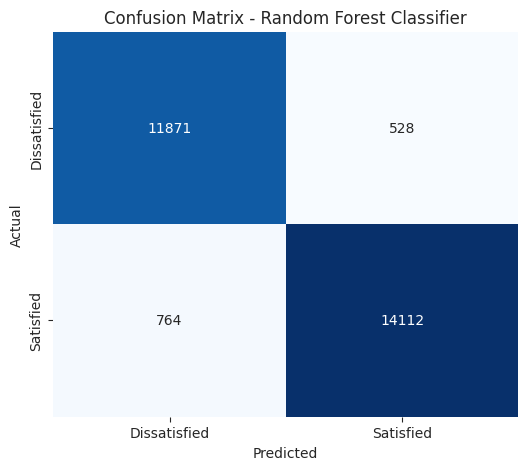

Training Decision Tree Classifier...
------------------------------
Evaluation for: Decision Tree Classifier
------------------------------
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     12399
           1       0.93      0.94      0.94     14876

    accuracy                           0.93     27275
   macro avg       0.93      0.93      0.93     27275
weighted avg       0.93      0.93      0.93     27275



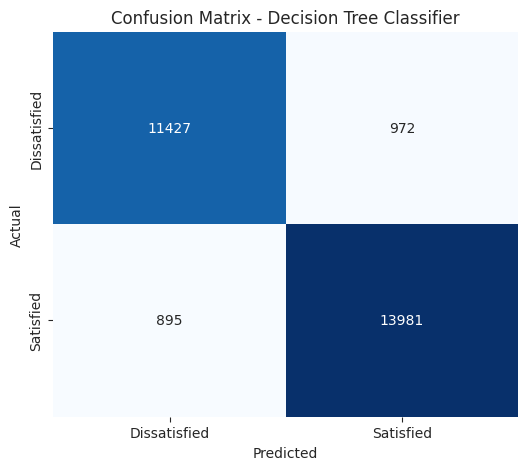

Training Naive Bayes...
------------------------------
Evaluation for: Naive Bayes
------------------------------
              precision    recall  f1-score   support

           0       0.80      0.79      0.79     12399
           1       0.82      0.84      0.83     14876

    accuracy                           0.81     27275
   macro avg       0.81      0.81      0.81     27275
weighted avg       0.81      0.81      0.81     27275



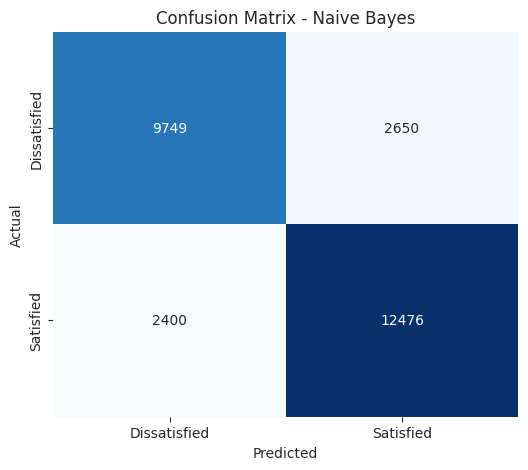

In [ ]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    evaluate_model(model, X_val_scaled, y_val, name)

In [ ]:
results = []

for name, model in models.items():
    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy')
    print(f'CV Score (Mean) {name}: {np.mean(cv_results)}')
    results.append(cv_results)

CV Score (Mean) K-Nearest Neighbors: 0.9009129348454524
CV Score (Mean) Logistic Regression: 0.8284124893109802
CV Score (Mean) Random Forest Classifier: 0.9504721892057865
CV Score (Mean) Decision Tree Classifier: 0.9290866086124567
CV Score (Mean) Naive Bayes: 0.8117879393040566


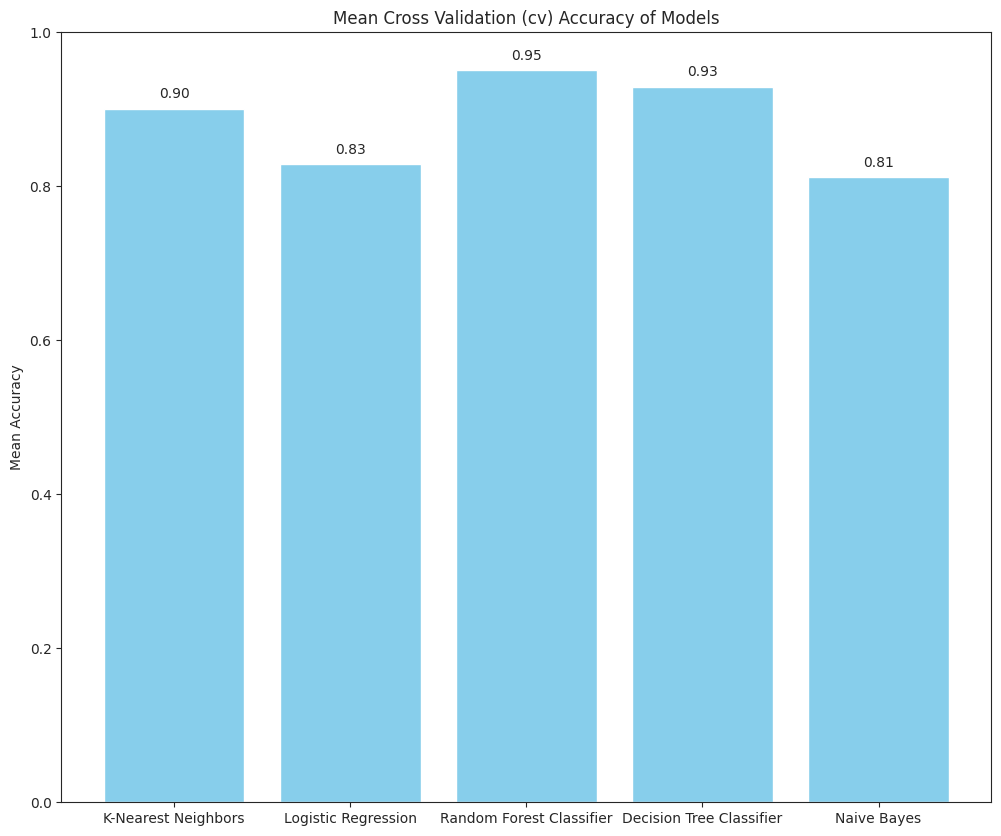

In [ ]:
model_names = list(models.keys())
mean_scores = [np.mean(cv) for cv in results]

plt.figure(figsize=(12,10))
bars = plt.bar(model_names, mean_scores, color='skyblue')
plt.ylabel('Mean Accuracy')
plt.ylim(0,1)
plt.title('Mean Cross Validation (cv) Accuracy of Models')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

plt.show()

# Hyperparameter tuning

## Hyperparameter Selection and Justification

**Logistic Regression**

The most important hyperparameter for Logistic Regression is C.

It controls the strength of regularization and therefore affects model complexity.

Small values of C create a simpler model and help reduce overfitting, while large values allow the model to fit the training data more closely.

The values [0.01, 0.1, 1, 10] were chosen to test different levels of regularization and find a balance between bias and variance.

**K-Nearest Neighbors (KNN)**

The main hyperparameter for KNN is n_neighbors.

It controls how many neighbors are used for prediction and directly affects overfitting and underfitting.

Small values can lead to overfitting, while larger values make the model more stable.

The values [3, 5, 7, 9] were selected to evaluate both low and moderate neighborhood sizes.

**Decision Tree Classifier**

The most important hyperparameter for Decision Trees is max_depth.

It controls the depth of the tree and the overall model complexity.

Deep trees may overfit the data, while limiting the depth improves generalization.

The values [None, 10, 20] were chosen to compare unrestricted and controlled tree growth.

**Random Forest Classifier**

For Random Forest, several hyperparameters were selected because they strongly influence model complexity and generalization.

n_estimators controls the number of trees, improving stability as it increases.

max_depth limits tree complexity and helps reduce overfitting.

min_samples_split and min_samples_leaf prevent trees from becoming overly complex.

The selected ranges were kept small to balance performance and computational cost.

**Naive Bayes (GaussianNB)**

Gaussian Naive Bayes has very few hyperparameters.

The most important one is var_smoothing, which improves numerical stability and helps control model variance.

Small values were tested to ensure stable probability estimation without overcomplicating the model.

In [ ]:
from sklearn.model_selection import GridSearchCV
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()

grid_knn = GridSearchCV(
    knn,
    knn_param_grid,
    cv=4,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Best KNN Params:", grid_knn.best_params_)
print("Best KNN Accuracy:", grid_knn.best_score_)

Best KNN Params: {'n_neighbors': 7, 'weights': 'distance'}
Best KNN Accuracy: 0.9002372384793936


In [ ]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr = LogisticRegression(max_iter=1000)

grid_lr = GridSearchCV(
    lr,
    lr_param_grid,
    cv=4,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR Accuracy:", grid_lr.best_score_)

Best LR Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR Accuracy: 0.8287267976437602


In [ ]:
dt_param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
    dt,
    dt_param_grid,
    cv=4,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train_scaled, y_train)

print("Best DT Params:", grid_dt.best_params_)
print("Best DT Accuracy:", grid_dt.best_score_)

Best DT Params: {'max_depth': 20, 'min_samples_split': 10}
Best DT Accuracy: 0.932339246344403


In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_model = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring='accuracy',
    cv=4,
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

print("Best parameters found:", grid_rf.best_params_)
print("Best Accuracy Score:", grid_rf.best_score_)

Fitting 4 folds for each of 48 candidates, totalling 192 fits
Best parameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy Score: 0.9502050344782007


In [ ]:
nb_param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

nb = GaussianNB()

grid_nb = GridSearchCV(
    nb,
    nb_param_grid,
    cv=4,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train_scaled, y_train)

print("Best NB Params:", grid_nb.best_params_)
print("Best NB Accuracy:", grid_nb.best_score_)


Best NB Params: {'var_smoothing': 1e-09}
Best NB Accuracy: 0.8118665853480002


# Performance Comparison (Before vs. After Tuning)

In [ ]:
def evaluate_models(models_dict, X_val, y_val):
    results = {}
    for name, model in models_dict.items():
        y_pred = model.predict(X_val)
        results[name] = accuracy_score(y_val, y_pred)
    return results

## Before Tuning

In [ ]:
models_before = models  # default models

results_before = evaluate_models(
    models_before,
    X_val_scaled,
    y_val
)

results_before

{'K-Nearest Neighbors': 0.9014482126489459,
 'Logistic Regression': 0.8294408799266728,
 'Random Forest Classifier': 0.9526306141154903,
 'Decision Tree Classifier': 0.9315490375802017,
 'Naive Bayes': 0.8148487626031164}

## After Tuning

In [ ]:
models_after = {
    'Logistic Regression': grid_lr.best_estimator_,
    'K-Nearest Neighbors': grid_knn.best_estimator_,
    'Decision Tree Classifier': grid_dt.best_estimator_,
    'Random Forest Classifier': grid_rf.best_estimator_,
    'Naive Bayes': grid_nb.best_estimator_
}

results_after = evaluate_models(
    models_after,
    X_val_scaled,
    y_val
)

results_after

{'Logistic Regression': 0.8286709440879927,
 'K-Nearest Neighbors': 0.9025847846012832,
 'Decision Tree Classifier': 0.9360219981668194,
 'Random Forest Classifier': 0.9527406049495876,
 'Naive Bayes': 0.8148487626031164}

## Performance Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Before Tuning Accuracy': results_before,
    'After Tuning Accuracy': results_after
})

comparison_df

,Before Tuning Accuracy,After Tuning Accuracy
K-Nearest Neighbors,0.901448,0.902585
Logistic Regression,0.829441,0.828671
Random Forest Classifier,0.952631,0.952741
Decision Tree Classifier,0.931549,0.936022
Naive Bayes,0.814849,0.814849


# Model Evaluation for models

## K-Nearest Neighbors Evaluation

Best KNN Params: {'n_neighbors': 7, 'weights': 'distance'}

Best KNN Accuracy: 0.9002372384793936

In [ ]:
knn_best = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance'
)

knn_best.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7, weights='distance')

In [ ]:
y_pred_knn = knn_best.predict(X_test_scaled)

------------------------------
Evaluation for: Tuned KNN
------------------------------
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     12399
           1       0.93      0.89      0.91     14876

    accuracy                           0.90     27275
   macro avg       0.90      0.90      0.90     27275
weighted avg       0.90      0.90      0.90     27275



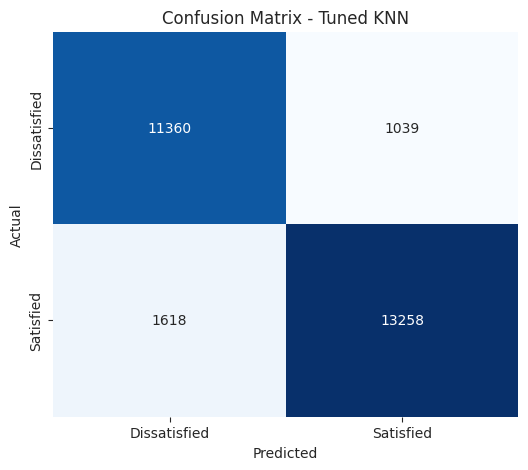

In [ ]:
evaluate_model(knn_best, X_val_scaled, y_val, "Tuned KNN")

## Logistic Regression	Evaluation

Best LR Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

Best LR Accuracy: 0.8287267976437602

In [ ]:
lr_best = LogisticRegression(
    C=0.01,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000
)

lr_best.fit(X_train_scaled, y_train)

LogisticRegression(C=0.01, max_iter=1000)

In [ ]:
y_pred_lr = lr_best.predict(X_test_scaled)

------------------------------
Evaluation for: Tuned Logistic Regression
------------------------------
              precision    recall  f1-score   support

           0       0.82      0.80      0.81     12399
           1       0.84      0.85      0.84     14876

    accuracy                           0.83     27275
   macro avg       0.83      0.83      0.83     27275
weighted avg       0.83      0.83      0.83     27275



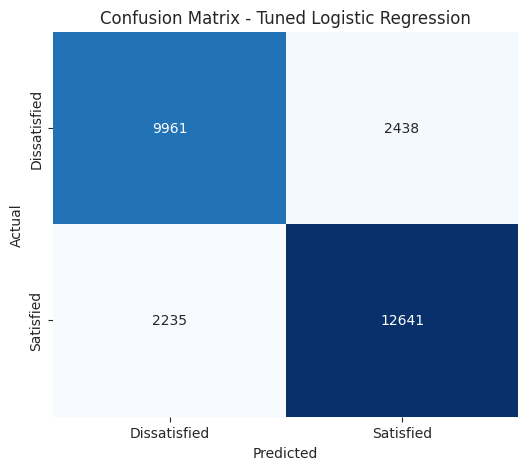

In [ ]:
evaluate_model(lr_best, X_val_scaled, y_val, "Tuned Logistic Regression")

## Decision Tree Evaluation

Best DT Params: {'max_depth': 20, 'min_samples_split': 10}

Best DT Accuracy: 0.932339246344403

In [ ]:
dt_best = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    random_state=42
)

dt_best.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=20, min_samples_split=10, random_state=42)

In [ ]:
y_pred_dt = dt_best.predict(X_test_scaled)

------------------------------
Evaluation for: Tuned Decision Tree
------------------------------
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     12399
           1       0.95      0.94      0.94     14876

    accuracy                           0.94     27275
   macro avg       0.94      0.94      0.94     27275
weighted avg       0.94      0.94      0.94     27275



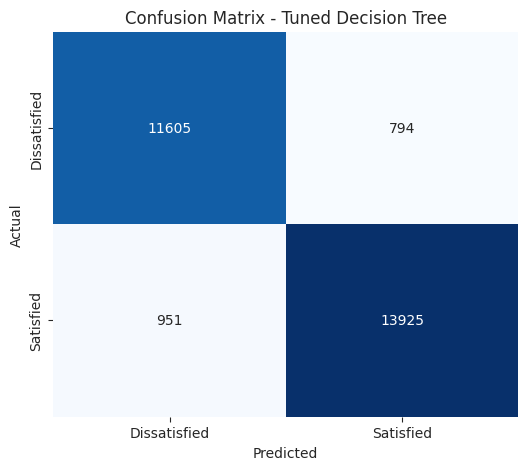

In [ ]:
evaluate_model(dt_best, X_val_scaled, y_val, "Tuned Decision Tree")

## Random Forest Evaluation

Best parameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

In [ ]:
rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

rf_best.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = rf_best.predict(X_test_scaled)

------------------------------
Evaluation for: Tuned Random Forest
------------------------------
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     12399
           1       0.96      0.95      0.96     14876

    accuracy                           0.95     27275
   macro avg       0.95      0.95      0.95     27275
weighted avg       0.95      0.95      0.95     27275



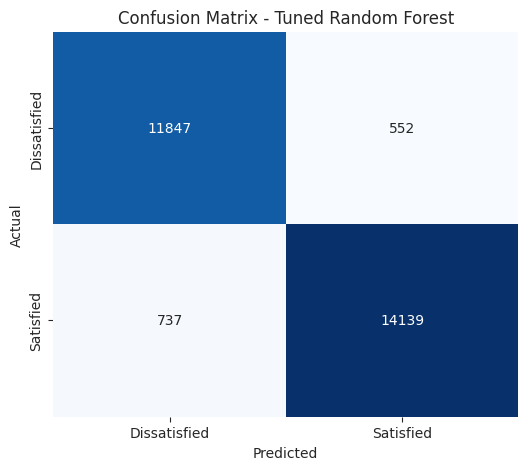

In [ ]:
evaluate_model(rf_best, X_val_scaled, y_val, "Tuned Random Forest")

## Naive Bayes evaluation

Best NB Params: {'var_smoothing': 1e-09}

Best NB Accuracy: 0.8118665853480002

In [ ]:
nb_best = GaussianNB(
    var_smoothing=1e-9
)

nb_best.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb_best.predict(X_test_scaled)

------------------------------
Evaluation for: Tuned Naive Bayes
------------------------------
              precision    recall  f1-score   support

           0       0.80      0.79      0.79     12399
           1       0.82      0.84      0.83     14876

    accuracy                           0.81     27275
   macro avg       0.81      0.81      0.81     27275
weighted avg       0.81      0.81      0.81     27275



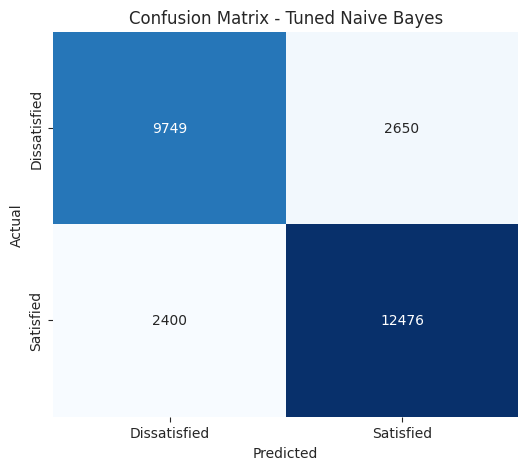

In [ ]:
evaluate_model(nb_best, X_val_scaled, y_val, "Tuned Naive Bayes")

# Model Comparison and Analysis

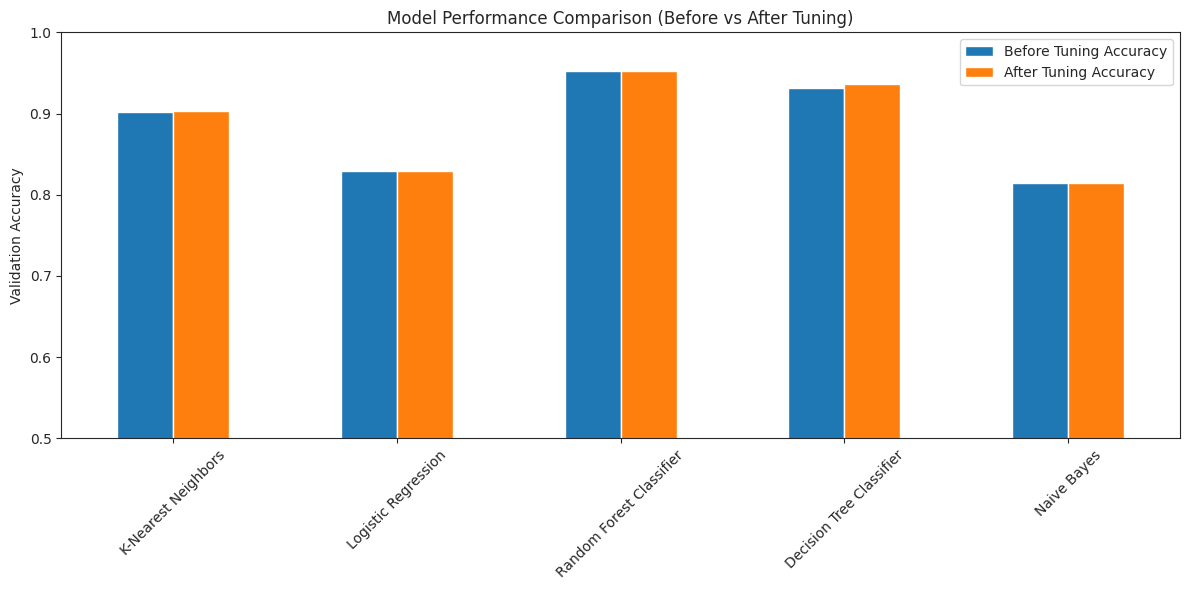

In [ ]:
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Performance Comparison (Before vs After Tuning)")
plt.ylabel("Validation Accuracy")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = comparison_df['After Tuning Accuracy'].idxmax()
final_model = models_after[best_model_name]

print("Best Final Model:", best_model_name)
print("Best Validation Accuracy:",
      comparison_df.loc[best_model_name, 'After Tuning Accuracy'])

Best Final Model: Random Forest Classifier
Best Validation Accuracy: 0.9527406049495876
